In [1]:
# Cell 1: The Engine
class MPNeuron:
    def __init__(self, weights, threshold):
        self.weights = weights
        self.threshold = threshold

    def predict(self, inputs):
        # Weighted sum of inputs
        weighted_sum = sum(w * x for w, x in zip(self.weights, inputs))
        # Threshold logic: if sum >= theta, fire (1), else stay silent (0)
        return 1 if weighted_sum >= self.threshold else 0

In [5]:
# Cell 2: Wiring the Brain
def xor_network(x1, x2):
    # OR Gate: Fires if either input is 1
    z1_neuron = MPNeuron(weights=[1, -1], threshold=1)
    z1 = z1_neuron.predict([x1, x2])

    # AND Gate: Fires only if both inputs are 1
    z2_neuron = MPNeuron(weights=[-1, 1], threshold=1)
    z2 = z2_neuron.predict([x1, x2])

    # Final Layer: Takes OR (z1) and subtracts AND (z2)
    # The weight -1 makes z2 inhibitory (it stops the neuron from firing)
    y_neuron = MPNeuron(weights=[1, 1], threshold=1)
    y = y_neuron.predict([z1, z2])

    return z1, z2, y

In [6]:
# Cell 3: Testing and Results
import pandas as pd

inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]
table_data = []

for x1, x2 in inputs:
    z1, z2, y = xor_network(x1, x2)
    table_data.append({
        "Input 1 (x1)": x1,
        "Input 2 (x2)": x2,
        "Hidden  (z1)": z1,
        "Hidden  (z2)": z2,
        "Final XOR (y)": y
    })

# Convert to DataFrame for a pretty Colab display
df = pd.DataFrame(table_data)
df

,Input 1 (x1),Input 2 (x2),Hidden (z1),Hidden (z2),Final XOR (y)
0,0,0,0,0,0
1,0,1,0,1,1
2,1,0,1,0,1
3,1,1,0,0,0


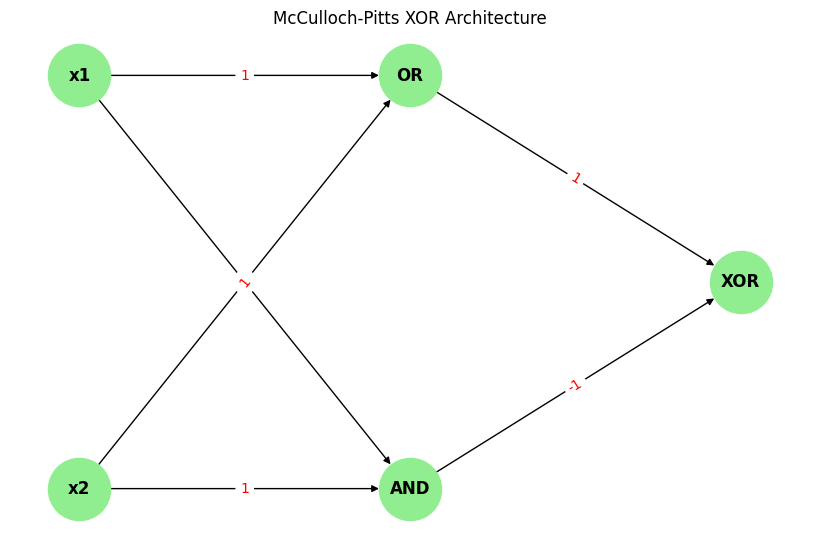

In [4]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_xor_network():
    G = nx.DiGraph()
    # Define nodes and positions
    nodes = {'x1': (0, 2), 'x2': (0, 0), 'OR': (1, 2), 'AND': (1, 0), 'XOR': (2, 1)}
    for node, pos in nodes.items():
        G.add_node(node, pos=pos)

    # Add weighted edges
    edges = [('x1', 'OR', 1), ('x1', 'AND', 1), ('x2', 'OR', 1),
             ('x2', 'AND', 1), ('OR', 'XOR', 1), ('AND', 'XOR', -1)]
    G.add_weighted_edges_from(edges)

    pos = nx.get_node_attributes(G, 'pos')
    plt.figure(figsize=(8, 5))
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightgreen', font_weight='bold')

    # Label weights
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_color='red')

    plt.title("McCulloch-Pitts XOR Architecture")
    plt.show()

draw_xor_network()